# Fair-RAG Experiment Runner

Runs a full Fair-RAG evaluation (EE + EU + Diversity) for a chosen model / ranker / reranker combination.

**How to use:**
1. Edit the toggles in **Cell 2** (Configuration).
2. Run all cells sequentially.
3. The run directory is printed at the end; artefacts live in `experiment_runs/<run_id>/`.

In [1]:
"""Cell 1 — Imports"""
import copy
import os
import sys

# Ensure repo root is importable when notebook cwd is the repo root
REPO_ROOT = os.path.abspath(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    ExperimentRunner,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    build_query_metric_rows,
    list_run_dirs,
    maybe_to_dataframe,
    setting_id,
)

print("Imports OK")

/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0415 17:56:02.694000 82209 .venv/lib/python3.11/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Imports OK


## Configuration

Edit the variables below, then run this cell before running the experiment.

| Toggle | Options |
|--------|---------|
| `DATASET_TYPE` | `"lamp"` (TREC-RAG: future) |
| `LAMP_NUM` | `1`–`7` |
| `LAMP_SPLIT_TYPE` | `"user"` \| `"time"` |
| `GENERATOR_NAME` | `"flanT5Small"` \| `"flanT5Base"` \| `"flanT5XXL"` \| `"bonsai8BMLX1bit"` \| `"lfm25MLX12B4bit"` \| `"qwen35MLX4B4bit"` |
| `RANKER` | `"bm25"` \| `"splade"` \| `"contriever"` \| `"gold"` |
| `RERANK_METHOD` | `"pl"` \| `"mmr"` \| `"deterministic"` |
| `TOP_K` | integer (documents per list) |
| `NUM_QUERIES` | integer or `None` (all) |
| `PL_SAMPLES` | number of stochastic PL samples (ignored for MMR/det) |
| `PL_ALPHA` | temperature (`1`=uniform, higher=more deterministic) |
| `MMR_LAMBDA` | `0.0`–`1.0` (higher=more relevance-focused) |
| `RESUME` | `True` to resume an interrupted run |
| `RUN_ID` | set to a previous run ID to resume; `None` = new run |

In [ ]:
# =============================================================================
# EXPERIMENT TOGGLES — edit these values to configure your run
# =============================================================================

# --- Execution mode ----------------------------------------------------------
RUN_MODE             = "batch"    # "single" | "batch"
REPORT_EVERY_QUERIES = 20         # print rolling avg EU / EE / diversity every N queries
RESUME               = False      # True = resume a previous interrupted run
RUN_ID               = None       # set to an existing run ID string to resume; None = new run
BATCH_ID             = "lamp4_bm25_mmr_pl_flow_test"  # optional explicit batch id

# --- Dataset -----------------------------------------------------------------
DATASET_TYPE    = "lamp"         # "lamp" (TREC-RAG: future)
LAMP_NUM        = 4              # LaMP task number (1–7)
LAMP_SPLIT_TYPE = "user"         # "user" | "time"
NUM_QUERIES     = None           # int or None (None = all queries)

# --- Retrieval ---------------------------------------------------------------
RANKER          = "bm25"         # "bm25" | "splade" | "contriever" | "gold"
TOP_K           = 5              # documents per ranked list

# --- Re-ranking --------------------------------------------------------------
RERANK_METHOD   = "pl"           # base default for single-run mode
PL_ALPHA        = 1              # PL temperature (higher = more deterministic)
PL_SAMPLES      = 10             # number of stochastic PL lists per query
MMR_LAMBDA      = 0.55           # MMR trade-off (1=fully relevance, 0=fully diverse)
SEED            = 42             # full-run seed used for reranking and generation

# --- Generator (LLM) ---------------------------------------------------------
GENERATOR_NAME  = "flanT5Small"  # e.g. "flanT5Small" | "flanT5Base" | "flanT5XXL"
MULTI_GPU       = False          # True to use distributed inference

# --- Metrics -----------------------------------------------------------------
COMPUTE_EE        = True         # Expected Exposure (EE-D, EE-R, EE-L)
COMPUTE_EU        = True         # Expected Utility (task-specific metric)
COMPUTE_DIVERSITY = True         # ILD-Jaccard + mean Jaccard similarity

# --- Flush/checkpoint cadence ------------------------------------------------
FLUSH_EVERY = 1                 # flush manifest after every N completed (qid, list_id) units

# =============================================================================
# Build base RunConfig from toggles
# =============================================================================

base_cfg = RunConfig(
    dataset=DatasetConfig(
        dataset_type=DATASET_TYPE,
        lamp_num=LAMP_NUM,
        lamp_split_type=LAMP_SPLIT_TYPE,
        num_queries=NUM_QUERIES,
    ),
    retrieval=RetrievalConfig(
        ranker=RANKER,
        top_k=TOP_K,
    ),
    rerank=RerankConfig(
        method=RERANK_METHOD,
        pl_alpha=PL_ALPHA,
        pl_samples=PL_SAMPLES,
        mmr_lambda=MMR_LAMBDA,
        seed=SEED,
    ),
    generation=GenerationConfig(
        generator_name=GENERATOR_NAME,
        multi_gpu=MULTI_GPU,
    ),
    metrics=MetricsConfig(
        compute_ee=COMPUTE_EE,
        compute_eu=COMPUTE_EU,
        compute_diversity=COMPUTE_DIVERSITY,
    ),
    checkpoint=CheckpointConfig(
        flush_every=FLUSH_EVERY,
        report_every_queries=REPORT_EVERY_QUERIES,
    ),
    resume=RESUME,
    run_id=RUN_ID,
)

# =============================================================================
# Batch overrides
# This test batch runs exactly the requested settings on LaMP 4 + BM25:
#   - MMR with lambda=0.55
#   - PL with alpha in {1, 2, 4, 8}
#   - deterministic BM25 baseline
#   - deterministic gold baseline
# =============================================================================

BATCH_OVERRIDES = [
    {
        "ranker": "bm25",
        "rerank_method": "mmr",
        "mmr_lambda": 0.55,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 1,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 2,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 4,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 8,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "deterministic",
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "gold",
        "rerank_method": "deterministic",
        "num_queries": None,
        "seed": 42,
    },
]


def build_cfg_from_override(base: RunConfig, override: dict) -> RunConfig:
    cfg = copy.deepcopy(base)
    if "generator_name" in override:
        cfg.generation.generator_name = override["generator_name"]
    if "ranker" in override:
        cfg.retrieval.ranker = override["ranker"]
    if "top_k" in override:
        cfg.retrieval.top_k = override["top_k"]
    if "num_queries" in override:
        cfg.dataset.num_queries = override["num_queries"]
    if "rerank_method" in override:
        cfg.rerank.method = override["rerank_method"]
    if "pl_alpha" in override:
        cfg.rerank.pl_alpha = override["pl_alpha"]
    if "pl_samples" in override:
        cfg.rerank.pl_samples = override["pl_samples"]
    if "mmr_lambda" in override:
        cfg.rerank.mmr_lambda = override["mmr_lambda"]
    if "seed" in override:
        cfg.rerank.seed = override["seed"]
    if "resume" in override:
        cfg.resume = override["resume"]
    if "run_id" in override:
        cfg.run_id = override["run_id"]
    return cfg


batch_cfgs = [build_cfg_from_override(base_cfg, item) for item in BATCH_OVERRIDES]

print("Base setting ID:", setting_id(base_cfg))
print("Run mode:", RUN_MODE)
if RUN_MODE == "batch":
    print("Batch setting IDs:")
    for cfg in batch_cfgs:
        print("  -", setting_id(cfg))

Base setting ID: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42
Run mode: batch
Batch setting IDs:
  - lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42
  - lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42
  - lamp4_user__flanT5Small__bm25__pl_a2_s10__k5__nq50__seed42
  - lamp4_user__flanT5Small__bm25__pl_a4_s10__k5__nq50__seed42
  - lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42
  - lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42
  - lamp4_user__flanT5Small__gold__det__k5__nq50__seed42


## Run Experiment

Execute the cell below to start the experiment.  
Progress is printed per query. Artefacts are saved incrementally under `experiment_runs/<run_id>/`.

In [3]:
if RUN_MODE == "single":
    runner = ExperimentRunner(base_cfg)
    run_output = runner.run()
    run_dirs = [run_output.run_dir]
else:
    batch_runner = BatchExperimentRunner(batch_cfgs, batch_id=BATCH_ID)
    batch_output = batch_runner.run_all()
    run_dirs = batch_output["run_dirs"]

print("Completed run directories:")
for path in run_dirs:
    print("  -", path)

[Batch] Starting run 1/7: lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42
Setting: lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 8997.40it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Setting: lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42 | Average after 20 queries: EE-D=1.0000, EE-R=0.1340, ILD=0.9449, EU=0.0279
Setting: lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42 | Average after 40 queries: EE-D=1.0000, EE-R=0.2020, ILD=0.9398, EU=0.0298
Setting: lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.2056, ILD=0.9395, EU=0.0323
Completed setting: lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_175639_lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_175639_lamp4_user__flanT5Small__bm25__mmr_l055__k5__nq50__seed42/macro_summary.json
[Batch] Starting run 2/7: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42
Setting: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 6018.79it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Setting: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42 | Average after 20 queries: EE-D=0.1732, EE-R=0.1656, ILD=0.9511, EU=0.0202
Setting: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42 | Average after 40 queries: EE-D=0.1518, EE-R=0.1945, ILD=0.9466, EU=0.0278
Setting: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42 | Average after 50 queries: EE-D=0.1471, EE-R=0.2136, ILD=0.9462, EU=0.0309
Completed setting: lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_175738_lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_175738_lamp4_user__flanT5Small__bm25__pl_a1_s10__k5__nq50__seed42/macro_summary.json
[Batch] Starting run 3/7: lamp4_user__flanT5Small__bm25__pl_a2_s10__k5__nq50__seed42
Setting: lamp4_user__flanT5Small__bm25__pl_a2_s10__k5__nq50__seed42


...

Setting: lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42 | Average after 20 queries: EE-D=0.9588, EE-R=0.1340, ILD=0.9432, EU=0.0252
Setting: lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42 | Average after 40 queries: EE-D=0.9693, EE-R=0.1975, ILD=0.9363, EU=0.0296
Setting: lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42 | Average after 50 queries: EE-D=0.9698, EE-R=0.2068, ILD=0.9350, EU=0.0318
Completed setting: lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_182658_lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_182658_lamp4_user__flanT5Small__bm25__pl_a8_s10__k5__nq50__seed42/macro_summary.json
[Batch] Starting run 6/7: lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42
Setting: lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 6133.39it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Setting: lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42 | Average after 20 queries: EE-D=1.0000, EE-R=0.1340, ILD=0.9443, EU=0.0278
Setting: lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42 | Average after 40 queries: EE-D=1.0000, EE-R=0.1970, ILD=0.9368, EU=0.0308
Setting: lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.2056, ILD=0.9353, EU=0.0329
Completed setting: lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_183548_lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_183548_lamp4_user__flanT5Small__bm25__det__k5__nq50__seed42/macro_summary.json
[Batch] Starting run 7/7: lamp4_user__flanT5Small__gold__det__k5__nq50__seed42
Setting: lamp4_user__flanT5Small__gold__det__k5__nq50__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 5537.42it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Setting: lamp4_user__flanT5Small__gold__det__k5__nq50__seed42 | Average after 20 queries: EE-D=1.0000, EE-R=0.9922, ILD=0.9509, EU=0.0644
Setting: lamp4_user__flanT5Small__gold__det__k5__nq50__seed42 | Average after 40 queries: EE-D=1.0000, EE-R=0.9956, ILD=0.9439, EU=0.0633
Setting: lamp4_user__flanT5Small__gold__det__k5__nq50__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.9965, ILD=0.9425, EU=0.0606
Completed setting: lamp4_user__flanT5Small__gold__det__k5__nq50__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_183646_lamp4_user__flanT5Small__gold__det__k5__nq50__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_183646_lamp4_user__flanT5Small__gold__det__k5__nq50__seed42/macro_summary.json
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_runs/batches/lamp4_bm25_mmr_pl_flow_test/batch_summary.json
Completed run directories:
  - /Users/asimk/Code/Fair-RAG/experiment_runs/20260415_175639_lamp4_user__flanT5S

## Results Summary

Inspect aggregated metrics across all processed queries.

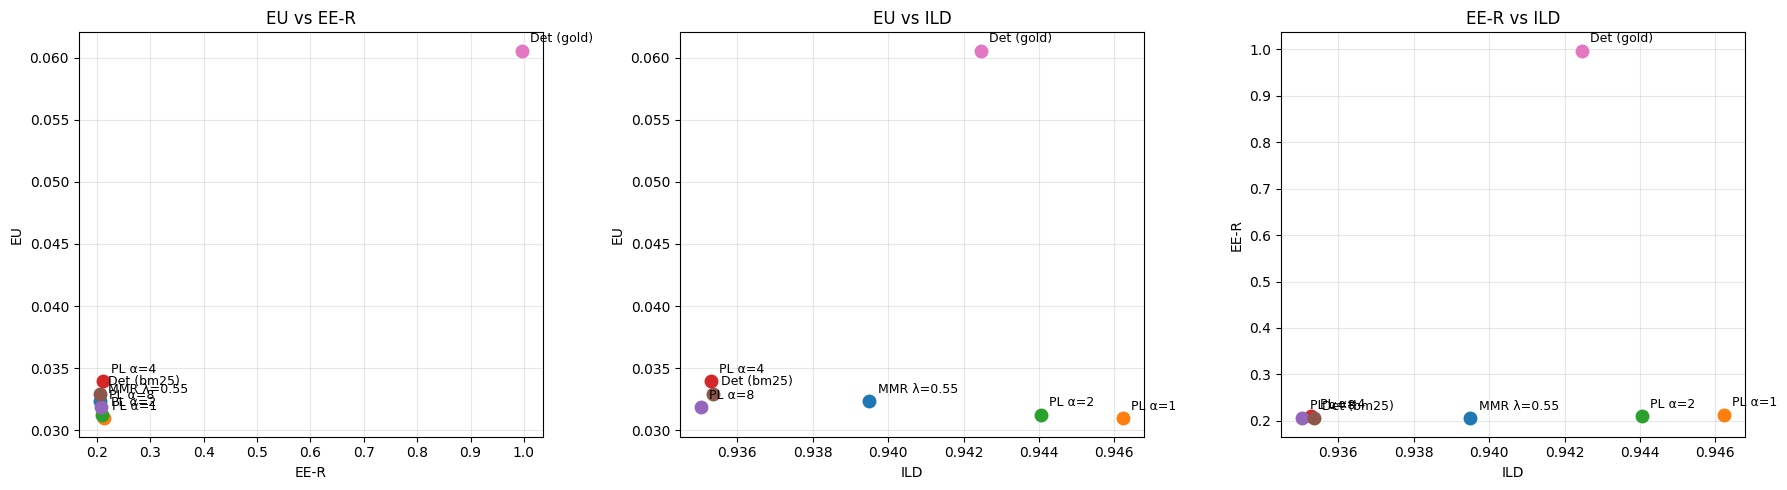

Macro comparison rows:


,n_queries,metric_name,expected_utility,max_utility,min_utility,avg_ild_jaccard,avg_jaccard_mean,ee_disparity,ee_relevance,ee_difference,...,lamp_split_type,generator_name,ranker,rerank_method,pl_alpha,pl_samples,mmr_lambda,top_k,num_queries_config,run_dir
0,50,rouge-l,0.032317,0.032317,0.032317,0.939500,0.060500,1.00000,0.205617,0.937976,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
1,50,rouge-l,0.030944,0.085414,0.001026,0.946229,0.053771,0.14712,0.213564,0.266375,...,user,flanT5Small,bm25,pl,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
2,50,rouge-l,0.031233,0.091048,0.002922,0.944050,0.055950,0.17504,0.210029,0.290446,...,user,flanT5Small,bm25,pl,2,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
3,50,rouge-l,0.033958,0.069582,0.013960,0.935287,0.064713,0.70192,0.210579,0.703637,...,user,flanT5Small,bm25,pl,4,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
4,50,rouge-l,0.031827,0.038768,0.026868,0.935031,0.064969,0.96984,0.206817,0.916382,...,user,flanT5Small,bm25,pl,8,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
5,50,rouge-l,0.032934,0.032934,0.032934,0.935342,0.064658,1.00000,0.205617,0.938833,...,user,flanT5Small,bm25,deterministic,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
6,50,rouge-l,0.060580,0.060580,0.060580,0.942453,0.057547,1.00000,0.996502,0.552723,...,user,flanT5Small,gold,deterministic,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...



Query-level rows for graphing:


,qid,metric_name,expected_utility,max_utility,min_utility,n_lists,avg_ild_jaccard,avg_jaccard_mean,ee_disparity,ee_relevance,...,lamp_split_type,generator_name,ranker,rerank_method,pl_alpha,pl_samples,mmr_lambda,top_k,num_queries_config,run_dir
0,312,rouge-l,0.000000,0.000000,0.000000,1,0.864317,0.135683,1.0,0.4,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
1,313,rouge-l,0.142857,0.142857,0.142857,1,0.910951,0.089049,1.0,0.2,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
2,315,rouge-l,0.027778,0.027778,0.027778,1,0.977661,0.022339,1.0,0.0,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
3,316,rouge-l,0.000000,0.000000,0.000000,1,0.968420,0.031580,1.0,0.2,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
4,317,rouge-l,0.000000,0.000000,0.000000,1,0.939822,0.060178,1.0,0.4,...,user,flanT5Small,bm25,mmr,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,3151,rouge-l,0.071429,0.071429,0.071429,1,0.933204,0.066796,1.0,1.0,...,user,flanT5Small,gold,deterministic,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
346,3152,rouge-l,0.000000,0.000000,0.000000,1,0.944985,0.055015,1.0,1.0,...,user,flanT5Small,gold,deterministic,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
347,3153,rouge-l,0.000000,0.000000,0.000000,1,0.933260,0.066740,1.0,1.0,...,user,flanT5Small,gold,deterministic,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
348,3154,rouge-l,0.048193,0.048193,0.048193,1,0.936815,0.063185,1.0,1.0,...,user,flanT5Small,gold,deterministic,1,10,0.55,5,50,/Users/asimk/Code/Fair-RAG/experiment_runs/202...



Loaded rows:
  Run-level rows  : 7
  Query-level rows: 350


In [ ]:
import matplotlib.pyplot as plt

macro_rows = build_macro_comparison_rows(run_dirs)

macro_table = maybe_to_dataframe(macro_rows)
query_table = None

def reranker_label(row):
    if row["rerank_method"] == "mmr":
        return f"MMR λ={row['mmr_lambda']}"
    if row["rerank_method"] == "deterministic":
        return f"Det ({row['ranker']})"
    return f"PL α={row['pl_alpha']}"


plot_rows = [row for row in macro_rows if row.get("ranker") != "gold"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plots = [
    ("ee_relevance", "expected_utility", "EE-R", "EU"),
    ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
    ("avg_ild_jaccard", "ee_relevance", "ILD", "EE-R"),
]

for ax, (x_key, y_key, x_label, y_label) in zip(axes, plots):
    for row in plot_rows:
        x = row.get(x_key)
        y = row.get(y_key)
        if x is None or y is None:
            continue
        label = reranker_label(row)
        ax.plot(x, y, marker="o", linestyle="None", markersize=9)
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs {x_label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Macro comparison rows:")
display(macro_table)

print("\nLoaded rows:")
print(f"  Run-level rows  : {len(macro_rows)}")
print("  Query-level rows: (hidden)")